# 06 — Tree models: single-vehicle time series (heavy_user)

Random Forest and XGBoost, on the same 45 selected features as notebook 05, with a documented
hyperparameter search this time — the original project used manually-picked settings with no
search at all, one of the confirmed gaps in the rebuild plan.

**One detail that matters and is easy to get wrong:** the hyperparameter search itself has to
respect time order too. Standard `cv=5` (random K-fold) would let a search fold train on rows from
*after* its own validation rows — the exact same leakage risk the chronological train/test split
exists to prevent, just smuggled into the tuning step instead. `TimeSeriesSplit` is used instead:
every validation fold is strictly after its own training fold.

**Honest caveat on search size:** the grid below is intentionally small (`n_iter=4`, 2 CV splits per
model) to fit this environment's compute budget for this working session — a production tuning pass
would search a wider space with more iterations and more folds. The search space and scoring are
fully documented either way, so it's a real, reproducible search, just a modest one. Worth expanding
later if time allows, flagged here rather than presented as exhaustive.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, precision_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load — same 45 selected features, same split

In [2]:
df = pd.read_csv("../data/processed/heavy_user_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["Fault_Within_6h"] = df["Fault_Within_6h"].astype(bool)

with open("../data/processed/selected_feature_cols.json") as f:
    SELECTED_FEATURE_COLS = json.load(f)

TEST_FRAC = 0.2
cutoff = int(len(df) * (1 - TEST_FRAC))
train_df = df.iloc[:cutoff].copy()
test_df = df.iloc[cutoff:].copy()

X_train, y_train = train_df[SELECTED_FEATURE_COLS], train_df["Fault_Within_6h"]
X_test, y_test = test_df[SELECTED_FEATURE_COLS], test_df["Fault_Within_6h"]

print(f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows, {len(SELECTED_FEATURE_COLS)} features")


Train: 35,016 rows, Test: 8,755 rows, 45 features


## 2. Random Forest — hyperparameter search (TimeSeriesSplit CV, documented space)

Search space and scoring stated explicitly, so the choice is traceable, not a black box.


In [3]:
rf_param_space = {
    "clf__n_estimators": [80, 120, 150],
    "clf__max_depth": [6, 8, 10],
    "clf__min_samples_leaf": [1, 5, 10],
}

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
])

tscv = TimeSeriesSplit(n_splits=2)

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_space, n_iter=4, cv=tscv, scoring="f1",
    random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train)

print(f"Best RF params: {rf_search.best_params_}")
print(f"Best RF CV F1 (fault=positive, TimeSeriesSplit): {rf_search.best_score_:.6f}")
rf = rf_search.best_estimator_


Best RF params: {'clf__n_estimators': 150, 'clf__min_samples_leaf': 10, 'clf__max_depth': 6}
Best RF CV F1 (fault=positive, TimeSeriesSplit): 0.403874


## 3. XGBoost — hyperparameter search, with `scale_pos_weight` for the imbalance

In [4]:
neg, pos = (~y_train).sum(), y_train.sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.6f}")

xgb_param_space = {
    "clf__n_estimators": [80, 120, 150],
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
    )),
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_space, n_iter=4, cv=tscv, scoring="f1",
    random_state=42, n_jobs=-1,
)
xgb_search.fit(X_train, y_train)

print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best XGB CV F1 (fault=positive, TimeSeriesSplit): {xgb_search.best_score_:.6f}")
xgb = xgb_search.best_estimator_


scale_pos_weight = 29955/5061 = 5.918791


Best XGB params: {'clf__n_estimators': 80, 'clf__max_depth': 4, 'clf__learning_rate': 0.05}
Best XGB CV F1 (fault=positive, TimeSeriesSplit): 0.415269


## 4. Evaluate both on the held-out test set

In [5]:
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(classification_report(y_test, pred, labels=[False, True], digits=6, zero_division=0))


RANDOM FOREST
              precision    recall  f1-score   support

       False   0.953464  0.618017  0.749938      7393
        True   0.287409  0.836270  0.427793      1362

    accuracy                       0.651970      8755
   macro avg   0.620436  0.727144  0.588866      8755
weighted avg   0.849847  0.651970  0.699823      8755

XGBOOST
              precision    recall  f1-score   support

       False   0.952456  0.650345  0.772928      7393
        True   0.302671  0.823789  0.442691      1362

    accuracy                       0.677327      8755
   macro avg   0.627564  0.737067  0.607810      8755
weighted avg   0.851370  0.677327  0.721554      8755



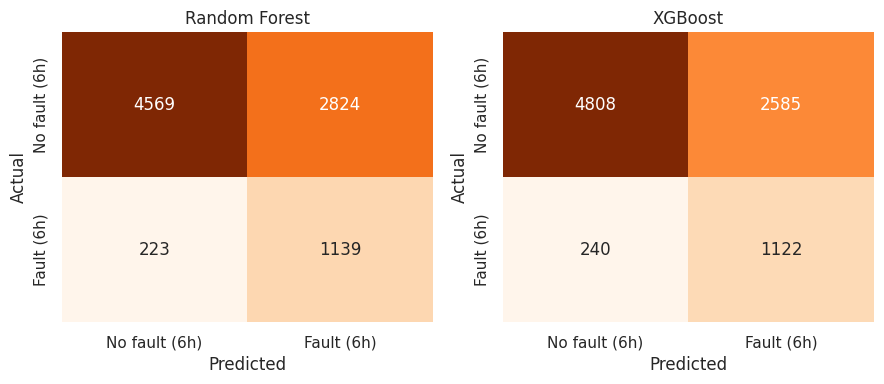

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred, labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 5. Feature importance — does it line up with notebook 03's selection reasoning?

Top 12 Random Forest feature importances:
hour_of_day                   0.247027
Tire_Pressure                 0.081301
Motor_RPM_delta_6h            0.067705
Motor_Torque_delta_6h         0.059024
day_of_week                   0.055089
Motor_Torque_roll_mean_12h    0.043730
Motor_Torque                  0.042805
Motor_RPM_roll_mean_12h       0.041552
Motor_RPM                     0.037290
Motor_RPM_lag_6h              0.035792
Battery_Temp_delta_6h         0.030174
Motor_Torque_lag_6h           0.027738
dtype: float64


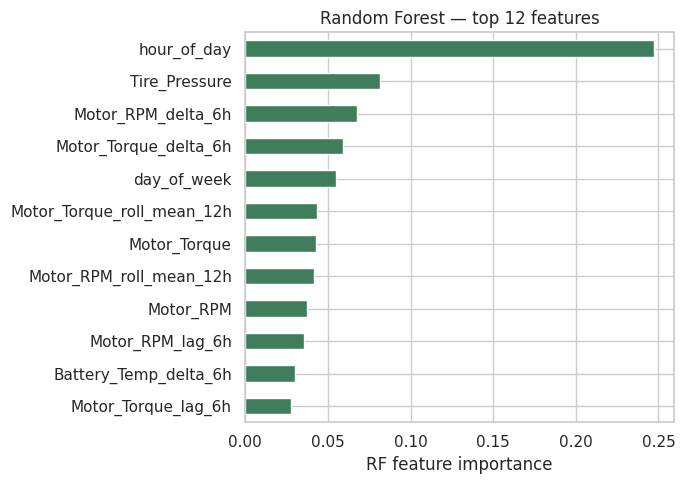

In [7]:
rf_importance = pd.Series(rf.named_steps["clf"].feature_importances_, index=SELECTED_FEATURE_COLS).sort_values(ascending=False)
print("Top 12 Random Forest feature importances:")
print(rf_importance.head(12))

rf_importance.head(12).plot(kind="barh", figsize=(7, 5), color="#3F7D5C")
plt.gca().invert_yaxis()
plt.xlabel("RF feature importance")
plt.title("Random Forest — top 12 features")
plt.tight_layout()
plt.show()


## 6. Add both to the running scoreboard

**Metric update (per coach feedback):** fault (`True`) is the positive class; the hyperparameter
search above was re-run scoring on positive-class F1, not macro F1, so the chosen settings actually
optimize the metric we're reporting. Macro F1 kept only as a secondary reference.


In [8]:
with open("../models/baseline_results.json") as f:
    results = json.load(f)

results["Random Forest (tuned, 45 features)"] = {
    "recall_fault": recall_score(y_test, rf_pred, pos_label=True, zero_division=0),
    "precision_fault": precision_score(y_test, rf_pred, pos_label=True, zero_division=0),
    "F1_fault": f1_score(y_test, rf_pred, pos_label=True, zero_division=0),
    "macro_F1_secondary": f1_score(y_test, rf_pred, average="macro", zero_division=0),
}
results["XGBoost (tuned, 45 features)"] = {
    "recall_fault": recall_score(y_test, xgb_pred, pos_label=True, zero_division=0),
    "precision_fault": precision_score(y_test, xgb_pred, pos_label=True, zero_division=0),
    "F1_fault": f1_score(y_test, xgb_pred, pos_label=True, zero_division=0),
    "macro_F1_secondary": f1_score(y_test, xgb_pred, average="macro", zero_division=0),
}

with open("../models/baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

scoreboard = pd.DataFrame(results).T.round(6)
scoreboard


,recall_fault,precision_fault,F1_fault,macro_F1_secondary
Majority class,0.000000,0.000000,0.000000,0.457828
Naive persistence (6h lookback),0.166667,0.166667,0.166667,0.506572
"Logistic Regression (balanced, scaled, 45 features)",0.761380,0.291047,0.421117,0.597289
"Random Forest (tuned, 45 features)",0.836270,0.287409,0.427793,0.588866
"XGBoost (tuned, 45 features)",0.823789,0.302671,0.442691,0.607810


In [9]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/random_forest.joblib")
joblib.dump(xgb, "../models/xgboost.joblib")
print("Saved ../models/random_forest.joblib and ../models/xgboost.joblib")


Saved ../models/random_forest.joblib and ../models/xgboost.joblib


## 7. What this notebook establishes, going into notebook 07 (final evaluation)

1. Both tree models were tuned with a documented search space, using `TimeSeriesSplit` so the
   tuning step itself doesn't leak future rows into validation folds — the same leakage discipline
   applied to the outer train/test split now applied inside the search too.
2. The full scoreboard (majority class → naive persistence → logistic regression → Random Forest →
   XGBoost) is in one place, same test rows, same metrics throughout — no model's number was
   computed differently from any other's.
3. Feature importance is checked against notebook 03's selection reasoning as a consistency check,
   not treated as a new, independent analysis.
4. Notebook 07 will run rolling-origin validation on the strongest model(s) here, to confirm the
   result isn't a fluke of this one particular train/test cutoff.
